# 01 · Análise exploratória

Base de treino: uma linha por município, **features de 2023 → resultado de 2024**. Alvo `risco = 1` quando o município **não** atingiu a meta.

Cada bloco termina com a decisão de modelagem que ele gerou. Os gráficos e números saem de `src/visualization/eda.py`; aqui fica a leitura.

In [1]:
import os, sys, json, warnings
warnings.filterwarnings("ignore")
os.chdir("..") if os.path.basename(os.getcwd()) == "notebooks" else None
sys.path.insert(0, os.getcwd())
import pandas as pd
from IPython.display import Image, display
pd.set_option("display.precision", 3)
from src.visualization import eda
base = pd.read_parquet("data/processed/base_treino.parquet")
base["variacao"] = base["_taxa_alvo"] - base["taxa_atual"]
print(base.shape, "| risco:", round(base.risco.mean(), 3))
base.head()

(5232, 20) | risco: 0.467


,taxa_atual,media_portugues,participacao,meta_alvo,_taxa_alvo,sigla_uf,regiao,nome_municipio,microrregiao,mesorregiao,populacao,pib_per_capita,log_populacao,log_pib_per_capita,porte_municipio,esforco_exigido,risco,ano_entrada,ano_alvo,variacao
id_municipio,,,,,,,,,,,,,,,,,,,,
1100015,64.55,758.330,89.37,67.08,67.79,RO,Norte,Alta Floresta D'Oeste,Cacoal,Leste Rondoniense,22516.0,32619.781,10.022,10.393,pequeno_II,2.53,0,2023,2024,3.24
1100023,62.30,757.100,89.79,65.22,65.62,RO,Norte,Ariquemes,Ariquemes,Leste Rondoniense,111148.0,28892.054,11.619,10.271,grande,2.92,0,2023,2024,3.32
1100031,69.10,767.876,90.48,70.85,75.88,RO,Norte,Cabixi,Colorado do Oeste,Leste Rondoniense,5067.0,47052.299,8.531,10.759,pequeno_I,1.75,0,2023,2024,6.78
1100049,62.51,755.564,84.44,65.39,65.81,RO,Norte,Cacoal,Cacoal,Leste Rondoniense,86416.0,32314.687,11.367,10.383,medio,2.88,0,2023,2024,3.30
1100056,58.53,746.463,92.12,62.09,66.81,RO,Norte,Cerejeiras,Colorado do Oeste,Leste Rondoniense,16088.0,46187.345,9.686,10.740,pequeno_I,3.56,0,2023,2024,8.28


## 1. Poder de separação de cada variável sozinha

AUC de 0,5 = não separa nada. Para as categóricas, cada categoria vira a taxa de risco do grupo, calculada **fora da própria partição** para não vazar o alvo.

In [2]:
eda.auc_univariada(base)

,variavel,auc,direcao
6,sigla_uf,0.730,categorica
7,regiao,0.639,categorica
2,participacao,0.608,maior -> menos risco
4,log_populacao,0.543,maior -> mais risco
8,porte_municipio,0.526,categorica
5,log_pib_per_capita,0.522,maior -> mais risco
1,media_portugues,0.516,maior -> menos risco
0,taxa_atual,0.515,maior -> mais risco
3,esforco_exigido,0.511,maior -> menos risco


**Leitura.** A UF sozinha chega a 0,73. Desempenho de 2023 (taxa, média de português) e esforço exigido quase não separam **isoladamente** (~0,51).

**Decisão:** UF entra no modelo, e a ancoragem estadual vira limitação documentada desde já.

## 2. Distribuições por classe

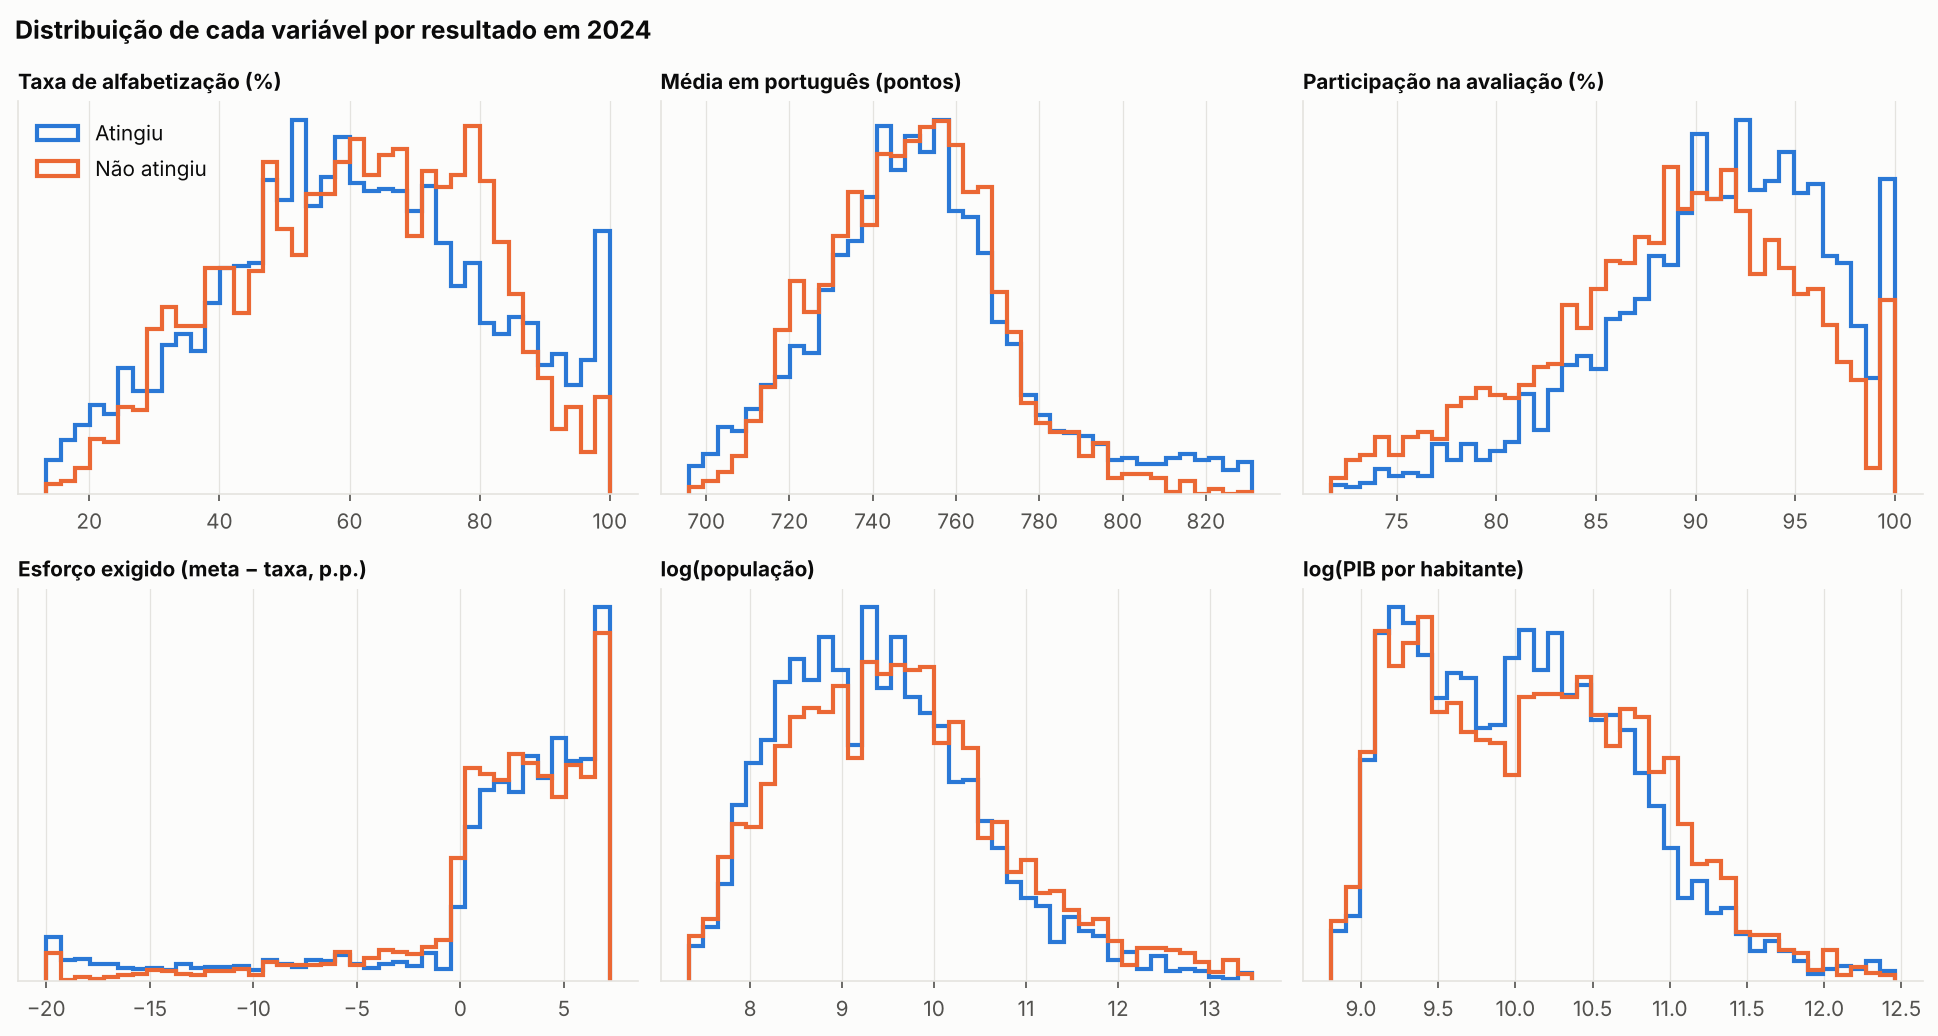

In [3]:
eda.grafico_distribuicoes(base)
display(Image('images/eda_distribuicoes.png'))

As curvas de taxa e esforço quase se sobrepõem. A meta de cada município é calculada a partir do próprio ponto de partida, então **ir bem em 2023 não facilita bater a meta de 2024**. Participação é a numérica mais deslocada.

## 3. Correlações

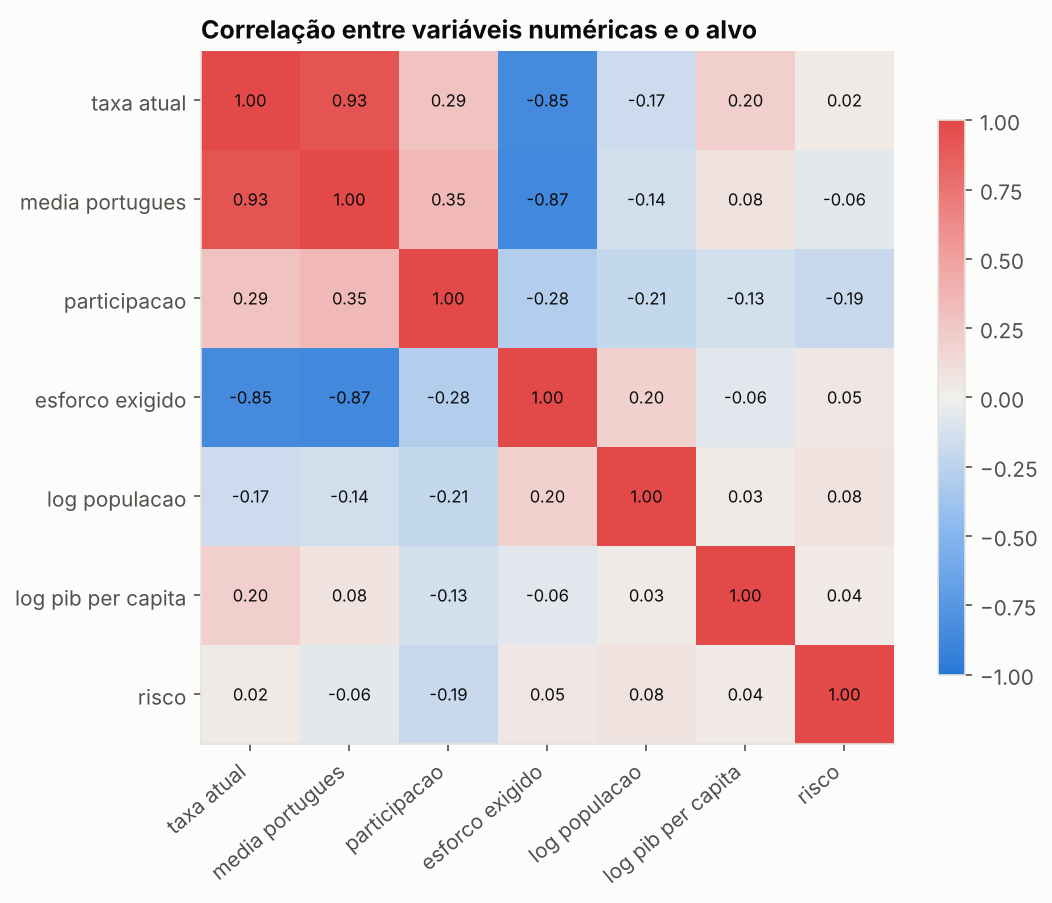

In [4]:
corr = eda.grafico_correlacoes(base)
display(Image('images/eda_correlacoes.png'))

Taxa × média de português: 0,93. Taxa × esforço: −0,85.

**Decisões:**
- `meta_alvo` sai do modelo: é exatamente `taxa_atual + esforco_exigido`. Com as três juntas, os coeficientes perdem leitura.
- `nivel_alfabetizacao` sai: é a faixa da própria taxa.
- Teste de estabilidade da importância em 8 sementes (a importância pode migrar entre variáveis correlacionadas).

## 4. Território

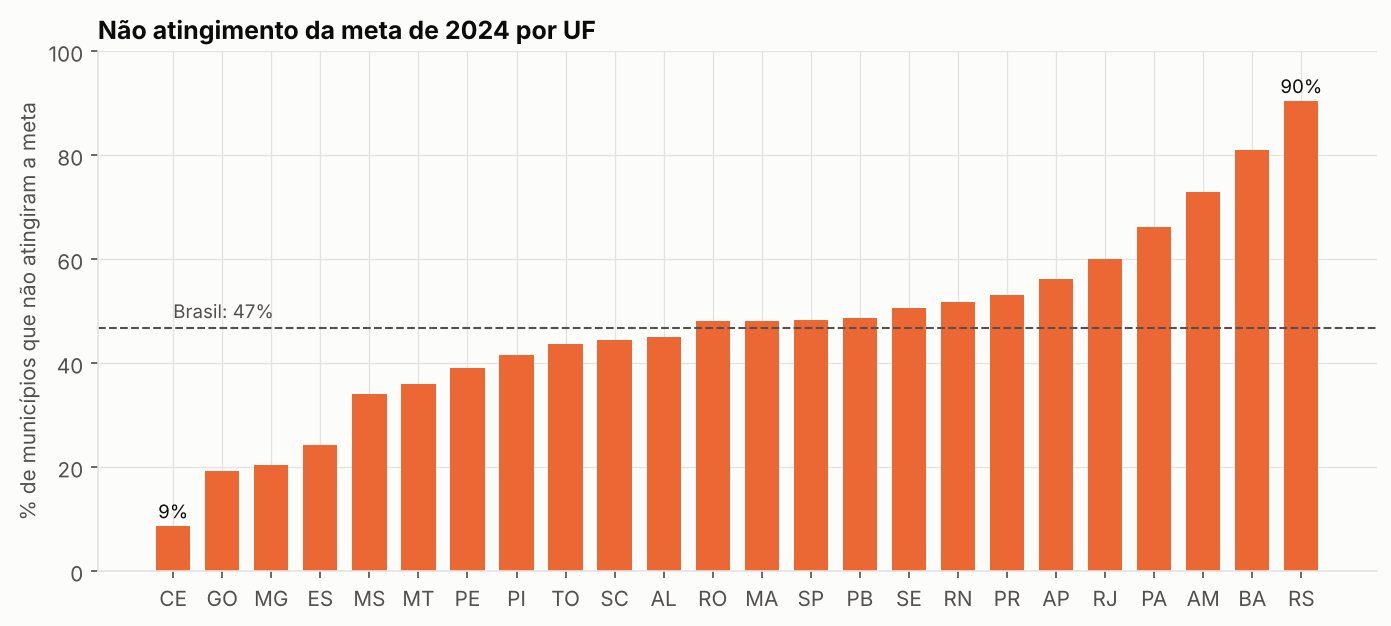

,municipios,risco
sigla_uf,,
CE,184,0.087
GO,243,0.193
BA,394,0.810
RS,421,0.905


In [5]:
uf = eda.grafico_risco_uf(base)
display(Image('images/eda_risco_por_uf.png'))
uf.sort_values('risco').iloc[[0, 1, -2, -1]]

Ceará 9% contra Rio Grande do Sul 90%. Amplitude de 82 p.p. entre estados.

In [6]:
eda.anomalia_rs(base)

{'variacao_media_rs': np.float64(-20.0),
 'variacao_media_demais': np.float64(4.8),
 'risco_rs': np.float64(90.5),
 'taxa_2023_rs': np.float64(73.1),
 'taxa_2023_demais': np.float64(59.4)}

**O RS caiu 20 p.p. em média de 2023 para 2024, enquanto o resto do país subiu 4,8.** As enchentes de abril e maio de 2024 fecharam escolas por semanas, e o MEC atribuiu a elas a queda do indicador nacional. É um **choque externo**, não gestão.

**Decisão:** sensibilidade sem o RS no treino, e o ranking de 2025 usa para o RS um modelo que não aprendeu o choque.

## 5. Riqueza

{'corr_entre_ufs': np.float64(-0.024),
 'corr_media_dentro_uf': np.float64(0.008)}

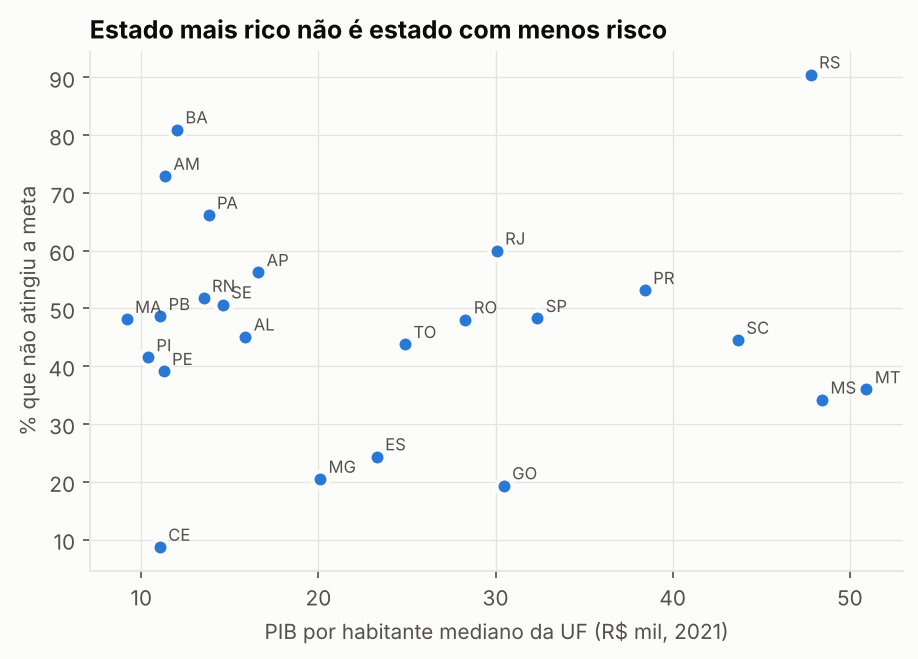

In [7]:
display(eda.riqueza_por_uf(base))
display(Image('images/eda_riqueza_vs_risco.png'))

Correlação entre PIB por habitante mediano da UF e risco: ~0. Dentro de cada UF também ~0. **O efeito estadual não é econômico.**

## 6. Hipótese: participação é ruído ou gestão?

,municipios,risco,variacao,volatilidade
participacao,,,,
< 85%,1070,0.598,0.276,16.141
85–90%,1309,0.521,2.472,15.784
90–95%,1730,0.421,3.622,16.675
≥ 95%,1123,0.351,4.243,17.455


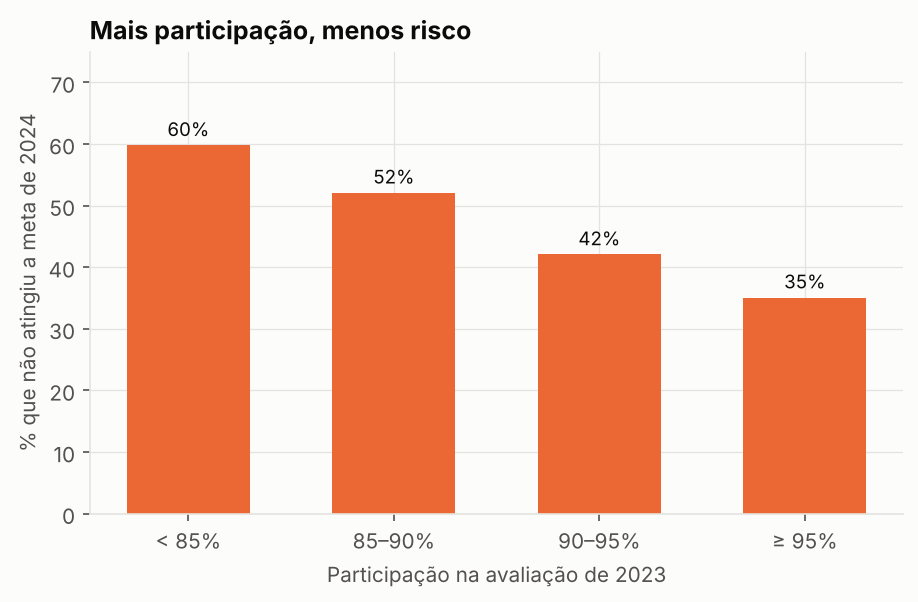

In [8]:
display(eda.grafico_participacao(base))
display(Image('images/eda_participacao.png'))

Hipótese inicial: participação baixa = amostra menor = indicador mais ruidoso. **Refutada:** a volatilidade é igual entre faixas (~16 p.p.). O que muda é a **direção**: +0,3 p.p. de melhora média abaixo de 85% contra +4,2 acima de 95%.

Participação é sinal de **capacidade de gestão** da rede (cadastro, frequência, comunicação com famílias), não de ruído.

**Decisão:** participação fica no modelo e entra nos perfis municipais.

## 7. Teto de previsibilidade

{'desvio_variacao': np.float64(16.6),
 'esforco_mediano': np.float64(3.2),
 'pct_esforco_negativo': 17.8,
 'pct_falharam_com_esforco_negativo': np.float64(44.9)}

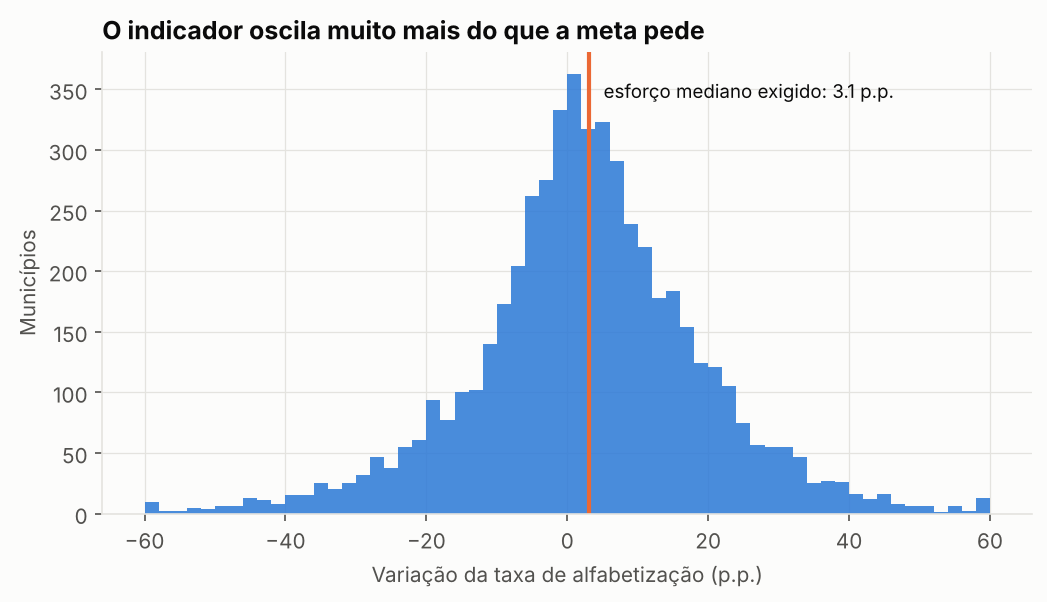

In [9]:
display(eda.grafico_teto(base))
display(Image('images/eda_teto_previsibilidade.png'))

In [10]:
q = pd.qcut(base.taxa_atual, 5)
base.groupby(q, observed=True)[['variacao', 'risco', 'esforco_exigido']].mean()

,variacao,risco,esforco_exigido
taxa_atual,,,
"(4.348999999999999, 42.824]",12.064,0.448,6.704
"(42.824, 55.54]",8.269,0.441,4.985
"(55.54, 66.5]",3.324,0.480,3.145
"(66.5, 78.492]",-0.705,0.503,1.218
"(78.492, 100.0]",-9.047,0.463,-7.712


- A taxa oscila com desvio de **16,6 p.p.** de um ano para outro; o esforço mediano exigido é **3,2 p.p.** O ruído é ~5× o sinal.
- **Regressão à média:** o quintil mais baixo de 2023 subiu 12 p.p.; o mais alto caiu 9. A meta já compensa isso em parte (exige mais de quem está embaixo), por isso o risco fica plano entre quintis.
- 18% dos municípios só precisavam não piorar, e 45% deles falharam.

**Decisão:** expectativa realista de AUC perto de 0,8. Um resultado muito acima disso seria sinal de vazamento.